# Descriptive Analysis: AI Exposure, Occupations, Employment & Wages

This notebook merges and replaces the earlier `descriptive_analysis.ipynb` and `descriptive_charts.ipynb` (kept separately, they had diverged and one still pointed at a stale file / wrong post-period cutoff).

**Contents**
1. Load panel & basic dimensions
2. Occupation & industry composition
3. High / Low exposure split (median split on LM_AIOE)
4. Employment trends by exposure group
5. Wage trends by exposure group
6. Distribution of LM_AIOE and MS_SCORE
7. LM_AIOE vs. MS_SCORE correlation
8. Pre/post summary table (simple descriptive DID)

**Sample**: 2012-2025, COVID years (2020-2021) excluded. Post period starts **2023** (2022 is the last pre-treatment year / event-time k=-1 reference), consistent with the DID/SC/GSC estimating equations.

## 1. Load panel & basic dimensions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

POST_START = 2023          # first post-treatment year (2022 = last pre-period year)
BASE_YEAR  = 2018           # index base year for trend charts

# ------------------------------------------------------------------
# Load data — this is the file actually saved by the merge pipeline
# (previous descriptive_charts.ipynb pointed at a filename missing '_ms_')
# ------------------------------------------------------------------
df = pd.read_csv('bls_onet_felten_ms_panel_harmonised.csv')

# Drop COVID years entirely — not shown, not analyzed
df = df[~df['year'].isin([2020, 2021])].copy()

df['TOT_EMP']  = pd.to_numeric(df['TOT_EMP'], errors='coerce')
df['H_MEDIAN'] = pd.to_numeric(df['H_MEDIAN'], errors='coerce')
df['A_MEDIAN'] = pd.to_numeric(df['A_MEDIAN'], errors='coerce')

print(f"Rows after dropping 2020-2021: {len(df)}")
print(f"Years remaining: {sorted(df['year'].unique())}")

Rows after dropping 2020-2021: 219783
Years remaining: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [3]:
# ------------------------------------------------------------------
# Panel dimensions overview
# ------------------------------------------------------------------
n_occ    = df['OCC_CODE'].nunique()
n_naics  = df['NAICS'].nunique()
n_years  = df['year'].nunique()
n_rows   = len(df)
n_aioe   = df['LM_AIOE'].notna().sum()
n_ms     = df['MS_SCORE'].notna().sum()

print('Panel dimensions')
print('-' * 40)
print(f'Unique occupations (OCC_CODE):     {n_occ}')
print(f'Unique industries (NAICS-3):       {n_naics}')
print(f'Unique years:                      {n_years}  ({sorted(df["year"].unique())[0]}-{sorted(df["year"].unique())[-1]}, COVID excluded)')
print(f'Total occupation x industry x year rows: {n_rows}')
print(f'Rows with LM_AIOE:                 {n_aioe} ({n_aioe/n_rows*100:.1f}%)')
print(f'Rows with MS_SCORE:                {n_ms} ({n_ms/n_rows*100:.1f}%)')

# Total employment covered by year (sanity check — should be roughly stable,
# large jumps flag a merge/dedup problem rather than a real labor market shift)
emp_by_year = df.groupby('year')['TOT_EMP'].sum().round(0)
print()
print('Total employment covered by year:')
print(emp_by_year)

Panel dimensions
----------------------------------------
Unique occupations (OCC_CODE):     889
Unique industries (NAICS-3):       96
Unique years:                      12  (2012-2025, COVID excluded)
Total occupation x industry x year rows: 219783
Rows with LM_AIOE:                 178979 (81.4%)
Rows with MS_SCORE:                203165 (92.4%)

Total employment covered by year:
year
2012    129717440.0
2013    131621200.0
2014    134105640.0
2015    136877310.0
2016    139491850.0
2017    141453560.0
2018    143317000.0
2019    145312240.0
2022    146994230.0
2023    150203590.0
2024    153257750.0
2025    154714170.0
Name: TOT_EMP, dtype: float64


## 2. Occupation & industry composition
Which occupations and industries actually make up the panel — useful context for interpreting the AIOE/MS_SCORE trends, and a sanity check that the collapse step (STEP 4 fix) didn't distort the employment totals for any particular occupation or industry.

In [4]:
# ------------------------------------------------------------------
# Top occupations by total employment (most recent year available)
# ------------------------------------------------------------------
latest_year = df['year'].max()
top_occ = (
    df[df['year'] == latest_year]
    .groupby(['OCC_CODE', 'OCC_TITLE'])['TOT_EMP']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
print(f'Top 15 occupations by total employment, {latest_year}:')
top_occ

Top 15 occupations by total employment, 2025:


,OCC_CODE,OCC_TITLE,TOT_EMP
0,31-1120,Home Health and Personal Care Aides,4302030.0
1,41-2031,Retail Salespersons,3892960.0
2,35-3023,Fast Food and Counter Workers,3848270.0
3,11-1021,General and Operations Managers,3503050.0
4,29-1141,Registered Nurses,3378750.0
5,41-2011,Cashiers,3088020.0
6,53-7062,"Laborers and Freight, Stock, and Material Move...",2949100.0
7,53-7065,Stockers and Order Fillers,2832040.0
8,43-4051,Customer Service Representatives,2594830.0
9,43-9061,"Office Clerks, General",2464340.0


In [5]:
# ------------------------------------------------------------------
# Top industries (NAICS-3) by total employment (most recent year)
# ------------------------------------------------------------------
top_naics = (
    df[df['year'] == latest_year]
    .groupby(['NAICS', 'NAICS_TITLE'])['TOT_EMP']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
print(f'Top 15 industries by total employment, {latest_year}:')
top_naics

Top 15 industries by total employment, 2025:


,NAICS,NAICS_TITLE,TOT_EMP
0,611000,Educational Services,13848450.0
1,722000,Food Services and Drinking Places,12254350.0
2,541000,"Professional, Scientific, and Technical Services",10781430.0
3,999000,"Federal, State, and Local Government, excludin...",10214100.0
4,621000,Ambulatory Health Care Services,8942050.0
5,561000,Administrative and Support Services,8470090.0
6,622000,Hospitals,6695990.0
7,238000,Specialty Trade Contractors,5235310.0
8,624000,Social Assistance,4968970.0
9,623000,Nursing and Residential Care Facilities,3392390.0


In [6]:
# ------------------------------------------------------------------
# Occupations with the highest / lowest AI exposure (LM_AIOE)
# One row per occupation — use the value merged onto any row, it is
# time-invariant, so 'first' is safe here.
# ------------------------------------------------------------------
occ_aioe = (
    df.dropna(subset=['LM_AIOE'])
    .groupby(['OCC_CODE', 'OCC_TITLE'])['LM_AIOE']
    .first()
    .reset_index()
)

print('10 highest-exposure occupations (LM_AIOE):')
display(occ_aioe.sort_values('LM_AIOE', ascending=False).head(10))

print('\n10 lowest-exposure occupations (LM_AIOE):')
display(occ_aioe.sort_values('LM_AIOE', ascending=True).head(10))

10 highest-exposure occupations (LM_AIOE):


,OCC_CODE,OCC_TITLE,LM_AIOE
424,41-9041,Telemarketers,1.925633
201,25-1123,"English Language and Literature Teachers, Post...",1.856860
202,25-1124,"Foreign Language and Literature Teachers, Post...",1.813892
203,25-1125,"History Teachers, Postsecondary",1.813362
197,25-1112,"Law Teachers, Postsecondary",1.801888
204,25-1126,"Philosophy and Religion Teachers, Postsecondary",1.799875
191,25-1067,"Sociology Teachers, Postsecondary",1.770457
189,25-1065,"Political Science Teachers, Postsecondary",1.769565
196,25-1111,"Criminal Justice and Law Enforcement Teachers,...",1.754122
137,19-3041,Sociologists,1.747498



10 lowest-exposure occupations (LM_AIOE):


,OCC_CODE,OCC_TITLE,LM_AIOE
645,51-6021,"Pressers, Textile, Garment, and Related Materials",-1.853906
525,47-3011,"Helpers--Brickmasons, Blockmasons, Stonemasons...",-1.821750
250,27-2031,Dancers,-1.793080
489,45-4021,Fallers,-1.791424
520,47-2171,Reinforcing Iron and Rebar Workers,-1.781242
528,47-3014,"Helpers--Painters, Paperhangers, Plasterers, a...",-1.711120
523,47-2221,Structural Iron and Steel Workers,-1.700957
503,47-2053,Terrazzo Workers and Finishers,-1.684962
502,47-2051,Cement Masons and Concrete Finishers,-1.677608
534,47-4031,Fence Erectors,-1.675288


## 3. High / Low exposure split (median split on LM_AIOE)

In [15]:
# ------------------------------------------------------------------
# Classify occupations into High / Low exposure using an
# occupation-level (time-invariant) median split on LM_AIOE.
# Occupations with missing LM_AIOE are explicitly excluded (NaN),
# not silently folded into "Low Exposure" — np.where would otherwise
# treat NaN >= median as False and misclassify them.
# ------------------------------------------------------------------
aioe_by_occ = df.groupby('OCC_CODE')['LM_AIOE'].first()
median_aioe = aioe_by_occ.median()

occ_map = df['OCC_CODE'].map(aioe_by_occ)

df['exposure_group'] = np.nan
df.loc[occ_map >= median_aioe, 'exposure_group'] = 'High Exposure'
df.loc[occ_map < median_aioe, 'exposure_group'] = 'Low Exposure'

n_missing = df['exposure_group'].isna().sum()
print(f'AIOE median (occupation-level): {median_aioe:.4f}')
print(f'Rows dropped from exposure comparison (missing LM_AIOE): {n_missing} ({n_missing/len(df)*100:.1f}%)')

# All downstream exposure-group comparisons (Sections 4, 5, 8) use this
# filtered frame instead of df, so occupations without an AIOE value
# never get counted as "Low Exposure" by default.
df_exposure = df.dropna(subset=['exposure_group']).copy()

colors = {'High Exposure': '#C0392B', 'Low Exposure': '#2980B9'}

print()
print('Occupation-year rows by exposure group:')
print(df_exposure['exposure_group'].value_counts())
print()
print('Unique occupations by exposure group:')
print(df_exposure.groupby('exposure_group')['OCC_CODE'].nunique())
print()
print(f'Employment share by exposure group, {latest_year}:')
share = df_exposure[df_exposure['year'] == latest_year].groupby('exposure_group')['TOT_EMP'].sum()
print((share / share.sum() * 100).round(1))

AIOE median (occupation-level): -0.1161
Rows dropped from exposure comparison (missing LM_AIOE): 40804 (18.6%)

Occupation-year rows by exposure group:
exposure_group
High Exposure    100161
Low Exposure      78818
Name: count, dtype: int64

Unique occupations by exposure group:
exposure_group
High Exposure    344
Low Exposure     344
Name: OCC_CODE, dtype: int64

Employment share by exposure group, 2025:
exposure_group
High Exposure    58.6
Low Exposure     41.4
Name: TOT_EMP, dtype: float64


In [16]:
n_missing_occ = aioe_by_occ.isna().sum()
print(f'Occupations with no LM_AIOE at all: {n_missing_occ}')

Occupations with no LM_AIOE at all: 201


## 4. Employment trends by exposure group
Indexed to 2018 = 100 (BASE_YEAR variable in the code cell below). Shaded region marks the **post-treatment period (2023 onward)** — 2022 is the last pre-treatment year (event-time k=-1), matching the estimating equations, not 2022 itself.

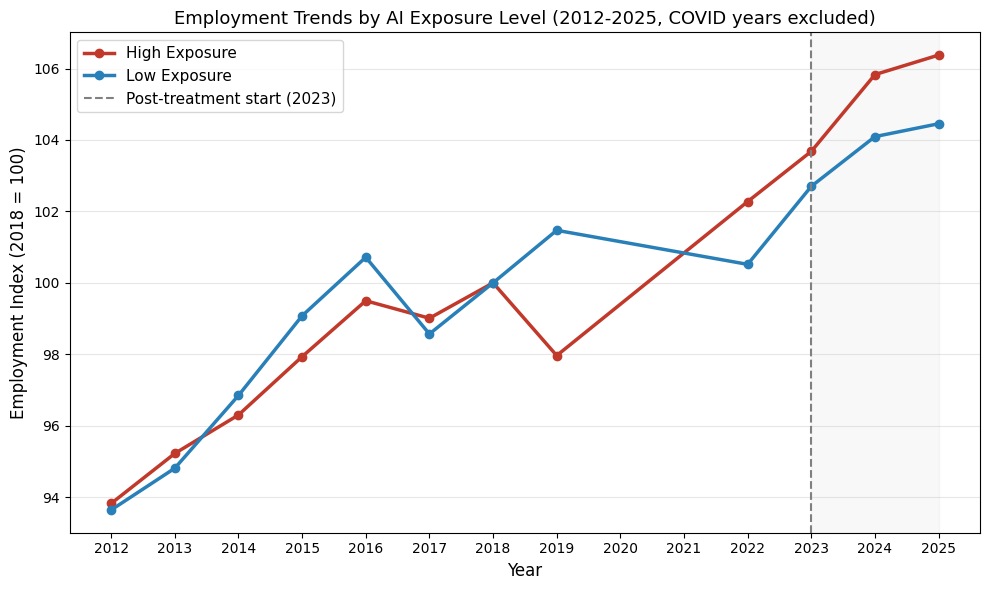

Saved descriptive_employment_trend.png


In [17]:
emp_agg = (
    df.groupby(['year', 'exposure_group'])['TOT_EMP']
    .sum()
    .reset_index()
)

base_emp = emp_agg[emp_agg['year'] == BASE_YEAR].set_index('exposure_group')['TOT_EMP']
emp_agg['emp_index'] = emp_agg.apply(
    lambda row: row['TOT_EMP'] / base_emp[row['exposure_group']] * 100, axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))
for group, gdf in emp_agg.groupby('exposure_group'):
    gdf = gdf.sort_values('year')
    ax.plot(gdf['year'], gdf['emp_index'],
            label=group, color=colors[group],
            linewidth=2.5, marker='o', markersize=6)

ax.axvline(x=POST_START, color='gray', linestyle='--', linewidth=1.5,
           label=f'Post-treatment start ({POST_START})')
ax.axvspan(POST_START, df['year'].max(), alpha=0.05, color='gray')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel(f'Employment Index ({BASE_YEAR} = 100)', fontsize=12)
ax.set_title(f'Employment Trends by AI Exposure Level ({df["year"].min()}-{df["year"].max()}, COVID years excluded)', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('descriptive_employment_trend.png', dpi=150)
plt.show()
print('Saved descriptive_employment_trend.png')

## 5. Wage trends by exposure group
Same treatment as employment: indexed to BASE_YEAR = 100, post period shaded from 2023.

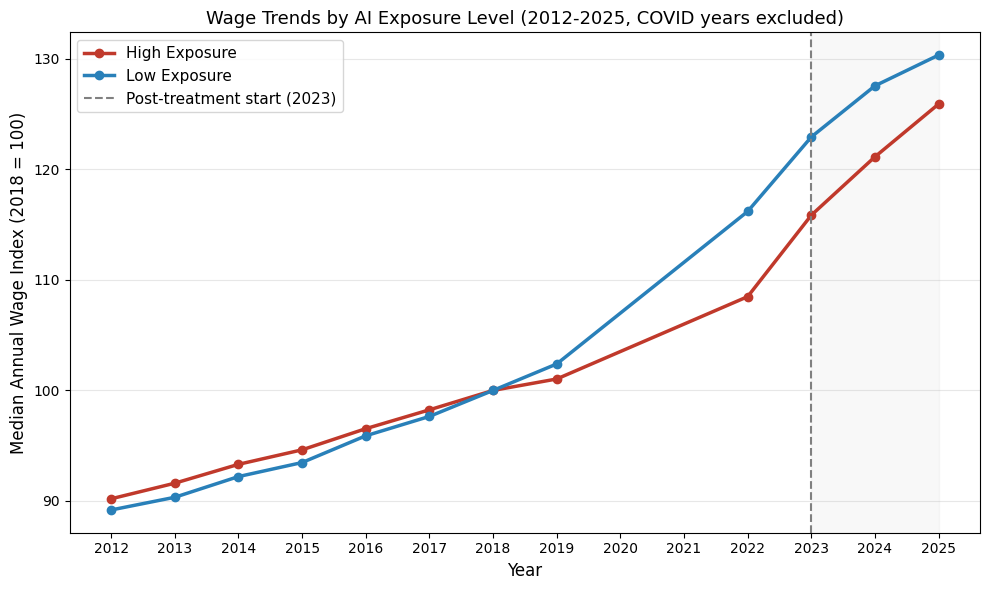

Saved descriptive_wage_trend.png


In [18]:
wage_agg = (
    df.groupby(['year', 'exposure_group'])['A_MEDIAN']
    .median()
    .reset_index()
)

base_wage = wage_agg[wage_agg['year'] == BASE_YEAR].set_index('exposure_group')['A_MEDIAN']
wage_agg['wage_index'] = wage_agg.apply(
    lambda row: row['A_MEDIAN'] / base_wage[row['exposure_group']] * 100, axis=1
)

fig, ax = plt.subplots(figsize=(10, 6))
for group, gdf in wage_agg.groupby('exposure_group'):
    gdf = gdf.sort_values('year')
    ax.plot(gdf['year'], gdf['wage_index'],
            label=group, color=colors[group],
            linewidth=2.5, marker='o', markersize=6)

ax.axvline(x=POST_START, color='gray', linestyle='--', linewidth=1.5,
           label=f'Post-treatment start ({POST_START})')
ax.axvspan(POST_START, df['year'].max(), alpha=0.05, color='gray')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel(f'Median Annual Wage Index ({BASE_YEAR} = 100)', fontsize=12)
ax.set_title(f'Wage Trends by AI Exposure Level ({df["year"].min()}-{df["year"].max()}, COVID years excluded)', fontsize=13)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('descriptive_wage_trend.png', dpi=150)
plt.show()
print('Saved descriptive_wage_trend.png')

## 6. Distribution of LM_AIOE and MS_SCORE
One occupation should appear once here, not once per occupation-year row, so we deduplicate first.

Unique occupations with both indices: 670


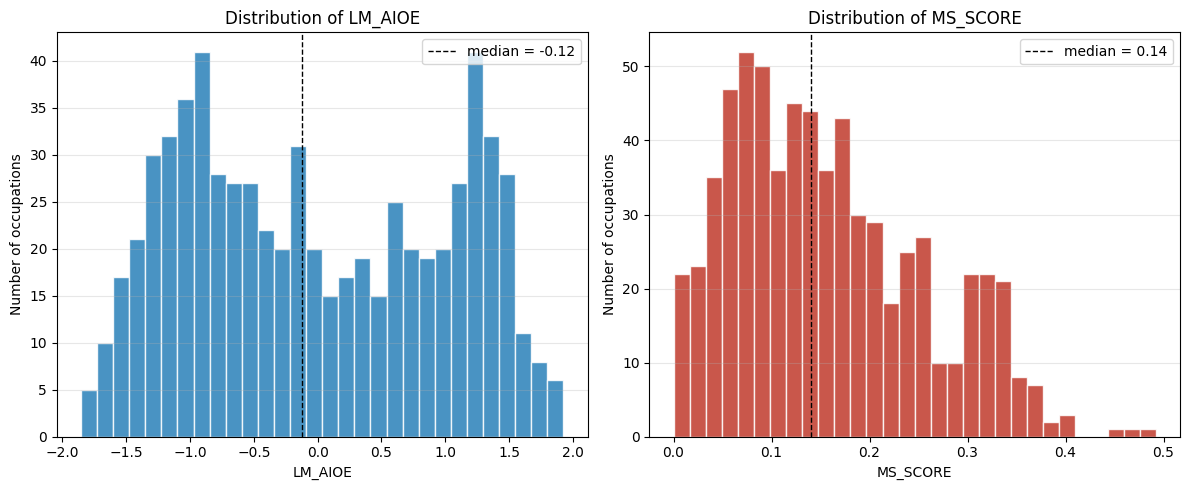

Saved index_distributions.png


In [19]:
occ_level = df.groupby('OCC_CODE').agg(
    OCC_TITLE=('OCC_TITLE', 'first'),
    LM_AIOE=('LM_AIOE', 'first'),
    MS_SCORE=('MS_SCORE', 'first')
).dropna(subset=['LM_AIOE', 'MS_SCORE']).reset_index()

print(f'Unique occupations with both indices: {len(occ_level)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(occ_level['LM_AIOE'], bins=30, color='#2980B9', edgecolor='white', alpha=0.85)
axes[0].axvline(occ_level['LM_AIOE'].median(), color='black', linestyle='--', linewidth=1,
                label=f"median = {occ_level['LM_AIOE'].median():.2f}")
axes[0].set_xlabel('LM_AIOE')
axes[0].set_ylabel('Number of occupations')
axes[0].set_title('Distribution of LM_AIOE')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(occ_level['MS_SCORE'], bins=30, color='#C0392B', edgecolor='white', alpha=0.85)
axes[1].axvline(occ_level['MS_SCORE'].median(), color='black', linestyle='--', linewidth=1,
                label=f"median = {occ_level['MS_SCORE'].median():.2f}")
axes[1].set_xlabel('MS_SCORE')
axes[1].set_ylabel('Number of occupations')
axes[1].set_title('Distribution of MS_SCORE')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('index_distributions.png', dpi=150)
plt.show()
print('Saved index_distributions.png')

## 7. LM_AIOE vs. MS_SCORE correlation
The r ≈ 0.72 relationship that likely drives the diverging employment-direction results across the two indices under a median split (they do not classify the same occupations as "high exposure").

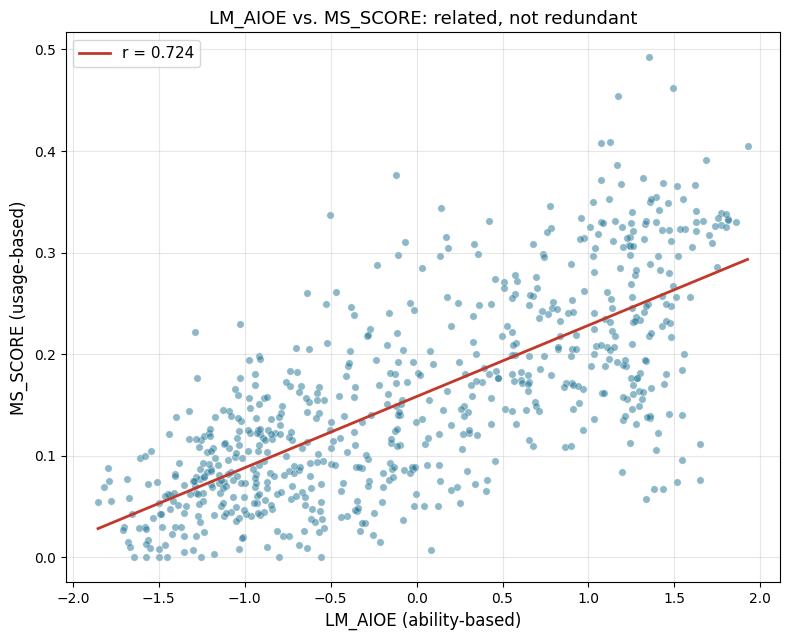

Correlation: 0.7239
Share of occupations classified the same way (high/low) by both indices under median split: 80.9%


In [20]:
corr = occ_level['LM_AIOE'].corr(occ_level['MS_SCORE'])

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.scatter(occ_level['LM_AIOE'], occ_level['MS_SCORE'],
           alpha=0.5, color='#1C7293', s=28, edgecolor='white', linewidth=0.4)

z = np.polyfit(occ_level['LM_AIOE'], occ_level['MS_SCORE'], 1)
x_line = np.linspace(occ_level['LM_AIOE'].min(), occ_level['LM_AIOE'].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color='#C0392B', linewidth=2,
        label=f'r = {corr:.3f}')

ax.set_xlabel('LM_AIOE (ability-based)', fontsize=12)
ax.set_ylabel('MS_SCORE (usage-based)', fontsize=12)
ax.set_title('LM_AIOE vs. MS_SCORE: related, not redundant', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('index_correlation_scatter.png', dpi=150)
plt.show()

# How much does the treated/control classification actually agree
# between the two indices under a median split? This is the concrete
# number behind 'conflicting employment directions across indices'.
occ_level['high_lm']  = occ_level['LM_AIOE']  >= occ_level['LM_AIOE'].median()
occ_level['high_ms']  = occ_level['MS_SCORE'] >= occ_level['MS_SCORE'].median()
agreement = (occ_level['high_lm'] == occ_level['high_ms']).mean()
print(f'Correlation: {corr:.4f}')
print(f'Share of occupations classified the same way (high/low) by both indices under median split: {agreement*100:.1f}%')

## 8. Pre/post summary table (descriptive DID)
A simple, non-parametric version of the DID contrast — mean employment and median wage, pre- (2012-2022) vs. post- (2023-2025) period, by exposure group. This is purely descriptive and does not control for the covariates or fixed effects in the formal estimating equations, but is a useful first look before the regression tables.

In [21]:
df['period'] = np.where(df['year'] >= POST_START, 'Post (2023-2025)', 'Pre (2012-2022)')

summary = (
    df.groupby(['exposure_group', 'period'])
    .agg(
        mean_emp   = ('TOT_EMP', 'mean'),
        median_wage = ('A_MEDIAN', 'median'),
        n_obs       = ('TOT_EMP', 'size'),
    )
    .reset_index()
)

summary_pivot = summary.pivot(index='exposure_group', columns='period', values=['mean_emp', 'median_wage'])
print('Pre/post summary by exposure group:')
summary_pivot.round(1)

Pre/post summary by exposure group:


mean_emp                      median_wage  \
period         Post (2023-2025) Pre (2012-2022) Post (2023-2025)   
exposure_group                                                     
High Exposure            8996.4          8213.8          73990.0   
Low Exposure             8539.0          7858.2          47580.0   

                                
period         Pre (2012-2022)  
exposure_group                  
High Exposure          59200.0  
Low Exposure           36400.0

In [ ]:
# Naive descriptive diff-in-diff (no controls, no FE — for context only)
pivot_emp = df.pivot_table(index='exposure_group', columns='period', values='TOT_EMP', aggfunc='mean')
pivot_wage = df.pivot_table(index='exposure_group', columns='period', values='A_MEDIAN', aggfunc='median')

emp_diff_high = pivot_emp.loc['High Exposure', 'Post (2023-2025)'] - pivot_emp.loc['High Exposure', 'Pre (2012-2022)']
emp_diff_low  = pivot_emp.loc['Low Exposure',  'Post (2023-2025)'] - pivot_emp.loc['Low Exposure',  'Pre (2012-2022)']
wage_diff_high = pivot_wage.loc['High Exposure', 'Post (2023-2025)'] - pivot_wage.loc['High Exposure', 'Pre (2012-2022)']
wage_diff_low  = pivot_wage.loc['Low Exposure',  'Post (2023-2025)'] - pivot_wage.loc['Low Exposure',  'Pre (2012-2022)']

print('Naive descriptive DID (no controls, no fixed effects — illustrative only):')
print(f'  Employment: (High post-pre) - (Low post-pre) = {emp_diff_high - emp_diff_low:,.1f}')s'sss
print(f'  Wage:       (High post-pre) - (Low post-pre) = {wage_diff_high - wage_diff_low:,.1f}')
print()
print('Note: this ignores occupation/industry fixed effects and covariates — see the DID/GSC')
print('regression notebooks for the identified estimates. This table is descriptive context only.')

Naive descriptive DID (no controls, no fixed effects — illustrative only):
  Employment: (High post-pre) - (Low post-pre) = 101.7
  Wage:       (High post-pre) - (Low post-pre) = 3,610.0

Note: this ignores occupation/industry fixed effects and covariates — see the DID/GSC
regression notebooks for the identified estimates. This table is descriptive context only.
